In [1]:
! pip install faraway

   ---------------------------------------- 0.0/224.5 kB ? eta -:--:--
   ---------------------------------------- 0.0/224.5 kB ? eta -:--:--
   - -------------------------------------- 10.2/224.5 kB ? eta -:--:--
   - -------------------------------------- 10.2/224.5 kB ? eta -:--:--
   ----- --------------------------------- 30.7/224.5 kB 262.6 kB/s eta 0:00:01
   ----- --------------------------------- 30.7/224.5 kB 262.6 kB/s eta 0:00:01
   ------- ------------------------------- 41.0/224.5 kB 179.6 kB/s eta 0:00:02
   ---------- ---------------------------- 61.4/224.5 kB 234.9 kB/s eta 0:00:01
   -------------- ------------------------ 81.9/224.5 kB 286.7 kB/s eta 0:00:01
   ---------------- ---------------------- 92.2/224.5 kB 291.5 kB/s eta 0:00:01
   ------------------- ------------------ 112.6/224.5 kB 285.2 kB/s eta 0:00:01
   ------------------------ ------------- 143.4/224.5 kB 327.9 kB/s eta 0:00:01
   -------------------------------- ----- 194.6/224.5 kB 421.8 kB/s eta 0:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from faraway.datasets import galapagos

In [2]:
data = galapagos.load()
print(data.head())

print(data.info())

           Species   Area  Elevation  Nearest  Scruz  Adjacent
Baltra          58  25.09        346      0.6    0.6      1.84
Bartolome       31   1.24        109      0.6   26.3    572.33
Caldwell         3   0.21        114      2.8   58.7      0.78
Champion        25   0.10         46      1.9   47.4      0.18
Coamano          2   0.05         77      1.9    1.9    903.82
<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, Baltra to Wolf
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Species    30 non-null     int64  
 1   Area       30 non-null     float64
 2   Elevation  30 non-null     int64  
 3   Nearest    30 non-null     float64
 4   Scruz      30 non-null     float64
 5   Adjacent   30 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 1.6+ KB
None


In [3]:
# Check data types
print(data.dtypes)

# Ensure no missing values
print(data.isnull().sum())

Species        int64
Area         float64
Elevation      int64
Nearest      float64
Scruz        float64
Adjacent     float64
dtype: object
Species      0
Area         0
Elevation    0
Nearest      0
Scruz        0
Adjacent     0
dtype: int64


In [4]:
# Define variables
X = data[['Area']]
y = data['Species']

# Check the dimensions
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (30, 1)
y shape: (30,)


In [5]:
# Add constant term to X
X = sm.add_constant(X)

# Inspect the first few rows of X to verify the constant column was added
print(X.head())

# Check the dimensions of X to ensure an additional column was added
print(f"X shape: {X.shape}")

           const   Area
Baltra       1.0  25.09
Bartolome    1.0   1.24
Caldwell     1.0   0.21
Champion     1.0   0.10
Coamano      1.0   0.05
X shape: (30, 2)


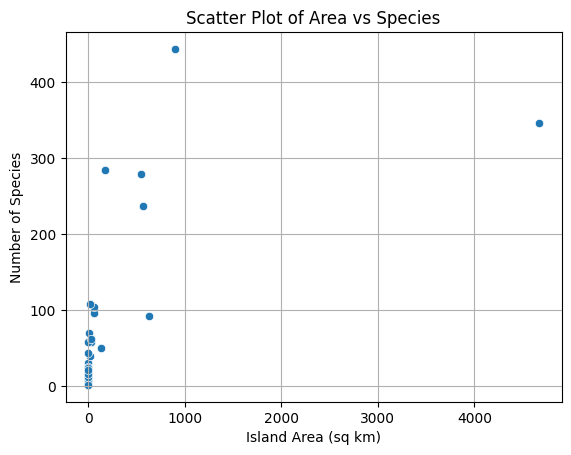

In [6]:
sns.scatterplot(x='Area', y='Species', data=data)
plt.title('Scatter Plot of Area vs Species')
plt.xlabel('Island Area (sq km)')
plt.ylabel('Number of Species')
plt.grid(True)
plt.show()

In [7]:
# Fit the regression model
model = sm.OLS(y, X).fit()

# Get regression coefficients
b0 = model.params['const']  # Intercept
b1 = model.params['Area']  # Slope


# Compute the correlation coefficient
r = np.corrcoef(data['Area'], data['Species'])[0, 1]


# Print the regression line equation and correlation coefficient
print(f"Regression Line: y = {b0:.2f} + {b1:.2f}x")
print(f"Correlation Coefficient (r): {r:.2f}")


# Print the model summary for additional details
print(model.summary())

Regression Line: y = 63.78 + 0.08x
Correlation Coefficient (r): 0.62
                            OLS Regression Results                            
Dep. Variable:                Species   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     17.29
Date:                Wed, 27 May 2026   Prob (F-statistic):           0.000275
Time:                        08:49:45   Log-Likelihood:                -177.10
No. Observations:                  30   AIC:                             358.2
Df Residuals:                      28   BIC:                             361.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

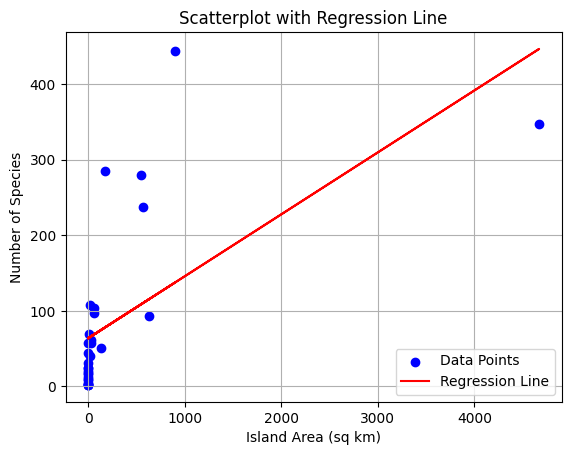

In [8]:
# Generate predicted values
y_pred = model.predict(X)

# Plot scatterplot with regression line
plt.scatter(data['Area'], data['Species'], color='blue', label='Data Points')
plt.plot(data['Area'], y_pred, color='red', label='Regression Line')
plt.title('Scatterplot with Regression Line')
plt.xlabel('Island Area (sq km)')
plt.ylabel('Number of Species')
plt.legend()
plt.grid(True)
plt.show()